# 📐 Chương 3: Tính Dừng (Stationarity)
## Advanced Data Science - Session 5

---

**Mục tiêu chương này:**
- Hiểu stationarity là gì và tại sao quan trọng
- Biết cách kiểm tra stationarity (ADF test, KPSS test)
- Nắm vững các kỹ thuật chuyển đổi: differencing, log, detrending
- Thực hành biến đổi dữ liệu non-stationary thành stationary

## 3.1 Stationarity Là Gì?

### 🎯 Ví dụ minh họa dễ hiểu:

**Tình huống 1 - Stationary (Dừng):**
Bạn tung xúc xắc 1000 lần, ghi lại kết quả theo thứ tự.
- Trung bình luôn ≈ 3.5, dù bạn xét 100 lần đầu hay 100 lần cuối
- Biên độ dao động không đổi
- → Đây là **STATIONARY** ✅

**Tình huống 2 - Non-Stationary (Không dừng):**
Bạn ghi lại giá nhà ở TP.HCM mỗi năm.
- 2010: trung bình 1 tỷ, 2020: trung bình 3 tỷ → **Mean thay đổi!**
- 2010: dao động ±200 triệu, 2020: dao động ±1 tỷ → **Variance thay đổi!**
- → Đây là **NON-STATIONARY** ❌

### 📐 Định nghĩa toán học:

Một time series Y(t) là **stationary** nếu:
1. **E[Y(t)] = μ** → Mean không đổi theo thời gian
2. **Var[Y(t)] = σ²** → Variance không đổi theo thời gian
3. **Cov[Y(t), Y(t+k)]** chỉ phụ thuộc vào k, không phụ thuộc t

### ⚠️ Tại sao PHẢI kiểm tra stationarity?

**Lý do 1:** Hầu hết model cổ điển (ARIMA, SARIMA) **YÊU CẦU** stationarity

**Lý do 2:** Nếu data non-stationary mà vẫn dùng → Kết quả **KHÔNG ĐÁNG TIN**

**Ví dụ thực tế:** Nếu dùng ARIMA trên data giá cổ phiếu (non-stationary) → Model sẽ cho rằng xu hướng tăng mãi → Dự đoán sai!

## 3.2 Các Loại Non-Stationary

### Type 1: Trend-Stationary
- Có trend nhưng sau khi loại bỏ trend → stationary
- **Cách xử lý:** Detrending (trừ đi trend)

### Type 2: Difference-Stationary
- Có unit root (random walk)
- **Cách xử lý:** Differencing: Y'(t) = Y(t) - Y(t-1)

### Type 3: Heteroscedastic (Variance thay đổi)
- Variance tăng theo thời gian
- **Cách xử lý:** Log transformation

---
## 🔬 Phần Thực Hành
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
print('✅ Import thành công!')

✅ Import thành công!


### 📝 Ví dụ 1: Visualize Stationary vs Non-Stationary

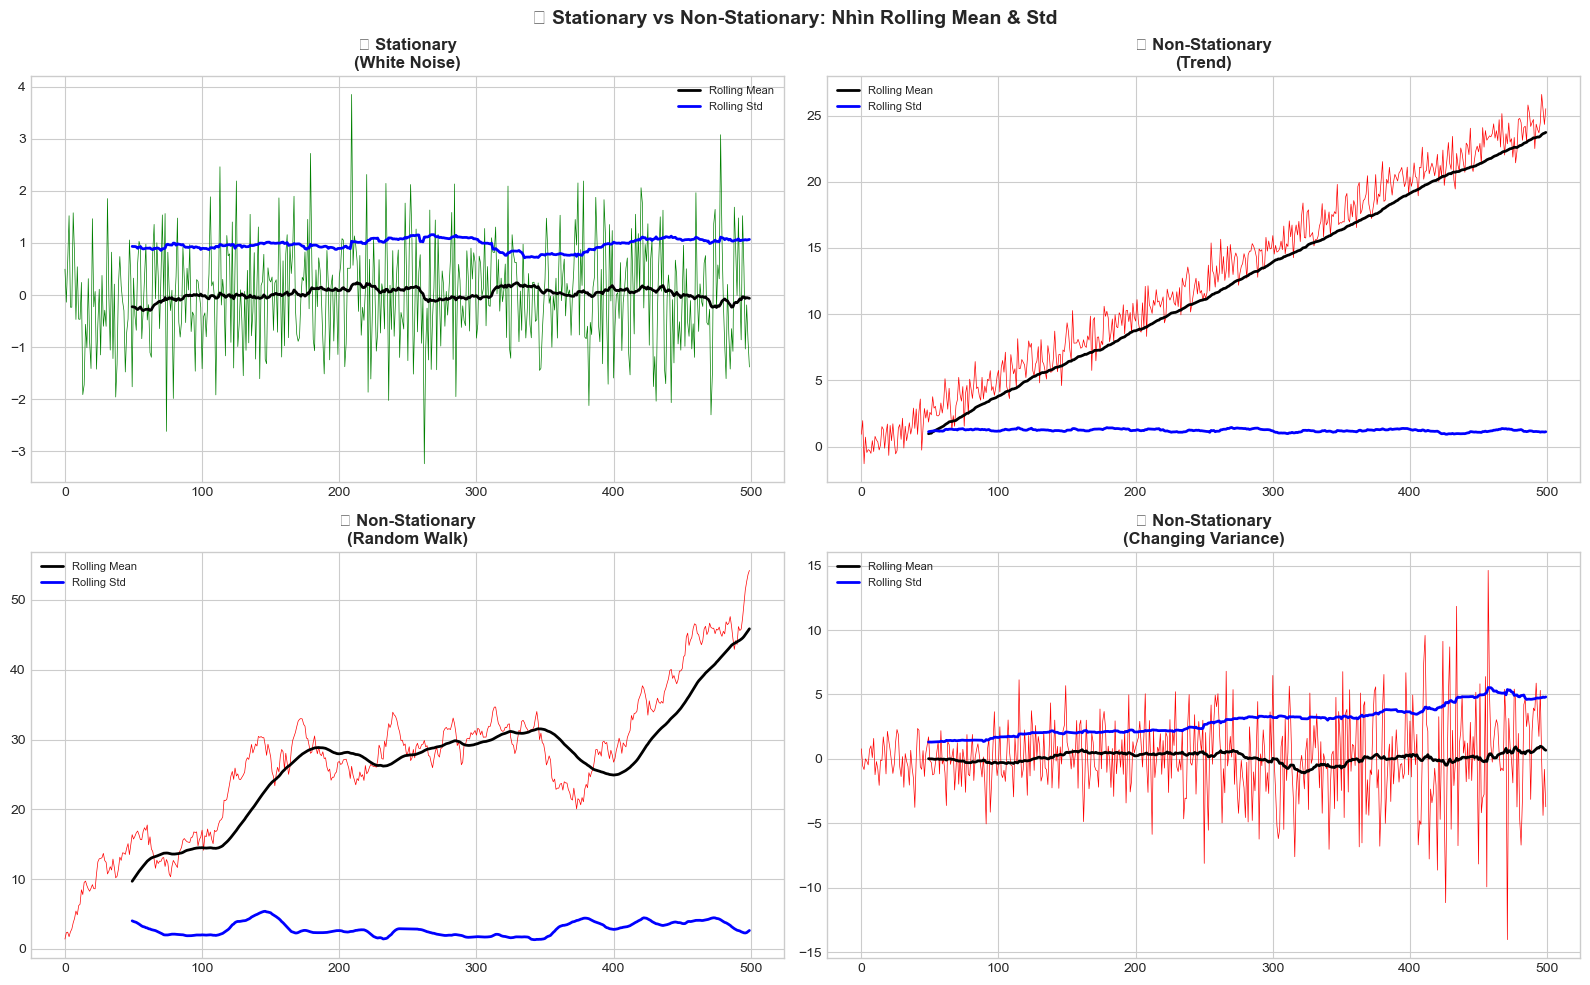

💡 Stationary: Rolling Mean & Std nằm ngang (không đổi)
💡 Non-Stationary: Rolling Mean hoặc Std thay đổi theo thời gian


In [2]:
# Tạo 4 loại time series khác nhau
np.random.seed(42)
n = 500

# 1. Stationary: white noise
y_stationary = np.random.normal(0, 1, n)

# 2. Non-stationary: có trend
y_trend = 0.05 * np.arange(n) + np.random.normal(0, 1, n)

# 3. Non-stationary: random walk (unit root)
y_random_walk = np.cumsum(np.random.normal(0, 1, n))
#cumsum là hàm tích lũy, tạo ra một chuỗi ngẫu nhiên có xu hướng đi lên hoặc đi xuống theo thời gian, không có tính ổn định.

# 4. Non-stationary: variance thay đổi
y_hetero = np.random.normal(0, 1, n) * np.linspace(1, 5, n)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
titles = [
    '✅ Stationary\n(White Noise)', 
    '❌ Non-Stationary\n(Trend)', 
    '❌ Non-Stationary\n(Random Walk)', 
    '❌ Non-Stationary\n(Changing Variance)'
]
data_list = [y_stationary, y_trend, y_random_walk, y_hetero]
colors = ['green', 'red', 'red', 'red']

for ax, y, title, color in zip(axes.flat, data_list, titles, colors):
    ax.plot(y, linewidth=0.5, color=color)
    # Rolling statistics
    s = pd.Series(y)
    ax.plot(s.rolling(50).mean(), color='black', linewidth=2, label='Rolling Mean')
    ax.plot(s.rolling(50).std(), color='blue', linewidth=2, label='Rolling Std')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.legend(fontsize=8)

plt.suptitle('🔍 Stationary vs Non-Stationary: Nhìn Rolling Mean & Std', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Stationary: Rolling Mean & Std nằm ngang (không đổi)')
print('💡 Non-Stationary: Rolling Mean hoặc Std thay đổi theo thời gian')

### 📝 Ví dụ 2: ADF Test (Augmented Dickey-Fuller)

**Đây là test QUAN TRỌNG NHẤT để kiểm tra stationarity!**

**Giả thuyết:**
- H₀ (Null): Dữ liệu **CÓ unit root** → NON-STATIONARY
- H₁ (Alternative): Dữ liệu **KHÔNG CÓ unit root** → STATIONARY

**Quyết định:**
- p-value < 0.05 → Bác bỏ H₀ → **STATIONARY** ✅
- p-value ≥ 0.05 → Không bác bỏ H₀ → **NON-STATIONARY** ❌

In [3]:
def adf_test(series, name=''):
    """
    Thực hiện Augmented Dickey-Fuller test
    
    Giải thích:
    - H₀: Series có unit root (NON-STATIONARY)
    - H₁: Series không có unit root (STATIONARY)
    - Bác bỏ H₀ khi p-value < 0.05
    """
    result = adfuller(series.dropna())
    
    print(f'╔══════════════════════════════════════╗')
    print(f'║   ADF Test: {name:24s} ║')
    print(f'╠══════════════════════════════════════╣')
    print(f'║  ADF Statistic : {result[0]:18.4f}  ║')
    print(f'║  p-value       : {result[1]:18.6f}  ║')
    print(f'║  # Lags Used   : {result[2]:18d}  ║')
    print(f'║  # Observations: {result[3]:18d}  ║')
    print(f'╠══════════════════════════════════════╣')
    print(f'║  Critical Values:                    ║')
    for key, value in result[4].items():
        print(f'║    {key:3s}: {value:30.4f}  ║')
    print(f'╠══════════════════════════════════════╣')
    
    if result[1] <= 0.05:
        print(f'║  ✅ p={result[1]:.4f} < 0.05              ║')
        print(f'║  → Bác bỏ H₀: STATIONARY            ║')
    else:
        print(f'║  ❌ p={result[1]:.4f} ≥ 0.05              ║')
        print(f'║  → Chấp nhận H₀: NON-STATIONARY     ║')
    print(f'╚══════════════════════════════════════╝')
    print()
    return result[1]

# Test trên 4 loại dữ liệu
print('🔬 Kiểm tra stationarity cho 4 loại time series:\n')
adf_test(pd.Series(y_stationary), 'White Noise')
adf_test(pd.Series(y_trend), 'Trend')
adf_test(pd.Series(y_random_walk), 'Random Walk')
adf_test(pd.Series(y_hetero), 'Changing Var')

🔬 Kiểm tra stationarity cho 4 loại time series:

╔══════════════════════════════════════╗
║   ADF Test: White Noise              ║
╠══════════════════════════════════════╣
║  ADF Statistic :           -22.3438  ║
║  p-value       :           0.000000  ║
║  # Lags Used   :                  0  ║
║  # Observations:                499  ║
╠══════════════════════════════════════╣
║  Critical Values:                    ║
║    1% :                        -3.4435  ║
║    5% :                        -2.8673  ║
║    10%:                        -2.5699  ║
╠══════════════════════════════════════╣
║  ✅ p=0.0000 < 0.05              ║
║  → Bác bỏ H₀: STATIONARY            ║
╚══════════════════════════════════════╝

╔══════════════════════════════════════╗
║   ADF Test: Trend                    ║
╠══════════════════════════════════════╣
║  ADF Statistic :            -0.3800  ║
║  p-value       :           0.913391  ║
║  # Lags Used   :                 18  ║
║  # Observations:                481  ║
╠═══

np.float64(1.2595120512102615e-23)

### 📝 Ví dụ 3: KPSS Test

**Giả thuyết NGƯỢC với ADF:**
- H₀: Series IS **STATIONARY**
- H₁: Series is **NON-STATIONARY**

**Nên dùng CẢ HAI test:**

| ADF | KPSS | Kết luận |
|-----|------|----------|
| Stationary | Stationary | ✅ Chắc chắn Stationary |
| Non-Stationary | Non-Stationary | ❌ Chắc chắn Non-Stationary |
| Stationary | Non-Stationary | ⚠️ Trend-Stationary |
| Non-Stationary | Stationary | ⚠️ Difference-Stationary |

In [4]:
def kpss_test(series, name=''):
    """
    KPSS Test
    H₀: Series IS stationary
    H₁: Series is NON-stationary
    """
    result = kpss(series.dropna(), regression='ct', nlags='auto')
    
    print(f'--- KPSS Test: {name} ---')
    print(f'  KPSS Statistic: {result[0]:.4f}')
    print(f'  p-value: {result[1]:.4f}')
    
    if result[1] < 0.05:
        print(f'  ❌ p={result[1]:.4f} < 0.05 → Bác bỏ H₀ → NON-STATIONARY')
    else:
        print(f'  ✅ p={result[1]:.4f} ≥ 0.05 → Chấp nhận H₀ → STATIONARY')
    print()
    return result[1]

def full_stationarity_test(series, name=''):
    """Chạy cả ADF và KPSS"""
    print(f'\n{"="*50}')
    print(f'  FULL STATIONARITY TEST: {name}')
    print(f'{"="*50}')
    p_adf = adf_test(series, name)
    p_kpss = kpss_test(series, name)
    
    adf_stat = p_adf < 0.05
    kpss_stat = p_kpss >= 0.05
    
    if adf_stat and kpss_stat:
        print('🎉 KẾT LUẬN: Chắc chắn STATIONARY')
    elif not adf_stat and not kpss_stat:
        print('⛔ KẾT LUẬN: Chắc chắn NON-STATIONARY')
    elif adf_stat and not kpss_stat:
        print('⚠️ KẾT LUẬN: Trend-Stationary (cần detrending)')
    else:
        print('⚠️ KẾT LUẬN: Difference-Stationary (cần differencing)')

# Test
full_stationarity_test(pd.Series(y_stationary), 'White Noise')
full_stationarity_test(pd.Series(y_random_walk), 'Random Walk')


  FULL STATIONARITY TEST: White Noise
╔══════════════════════════════════════╗
║   ADF Test: White Noise              ║
╠══════════════════════════════════════╣
║  ADF Statistic :           -22.3438  ║
║  p-value       :           0.000000  ║
║  # Lags Used   :                  0  ║
║  # Observations:                499  ║
╠══════════════════════════════════════╣
║  Critical Values:                    ║
║    1% :                        -3.4435  ║
║    5% :                        -2.8673  ║
║    10%:                        -2.5699  ║
╠══════════════════════════════════════╣
║  ✅ p=0.0000 < 0.05              ║
║  → Bác bỏ H₀: STATIONARY            ║
╚══════════════════════════════════════╝

--- KPSS Test: White Noise ---
  KPSS Statistic: 0.0773
  p-value: 0.1000
  ✅ p=0.1000 ≥ 0.05 → Chấp nhận H₀ → STATIONARY

🎉 KẾT LUẬN: Chắc chắn STATIONARY

  FULL STATIONARITY TEST: Random Walk
╔══════════════════════════════════════╗
║   ADF Test: Random Walk              ║
╠═══════════════════════

### 📝 Ví dụ 4: Differencing - Biến Đổi Thành Stationary

**Differencing:** Lấy sai phân → Loại bỏ trend

```
Y'(t) = Y(t) - Y(t-1)     ← First-order differencing (d=1)
Y''(t) = Y'(t) - Y'(t-1)   ← Second-order differencing (d=2)
```

**Ý nghĩa:** Thay vì nhìn giá trị, ta nhìn **sự thay đổi** giữa các thời điểm

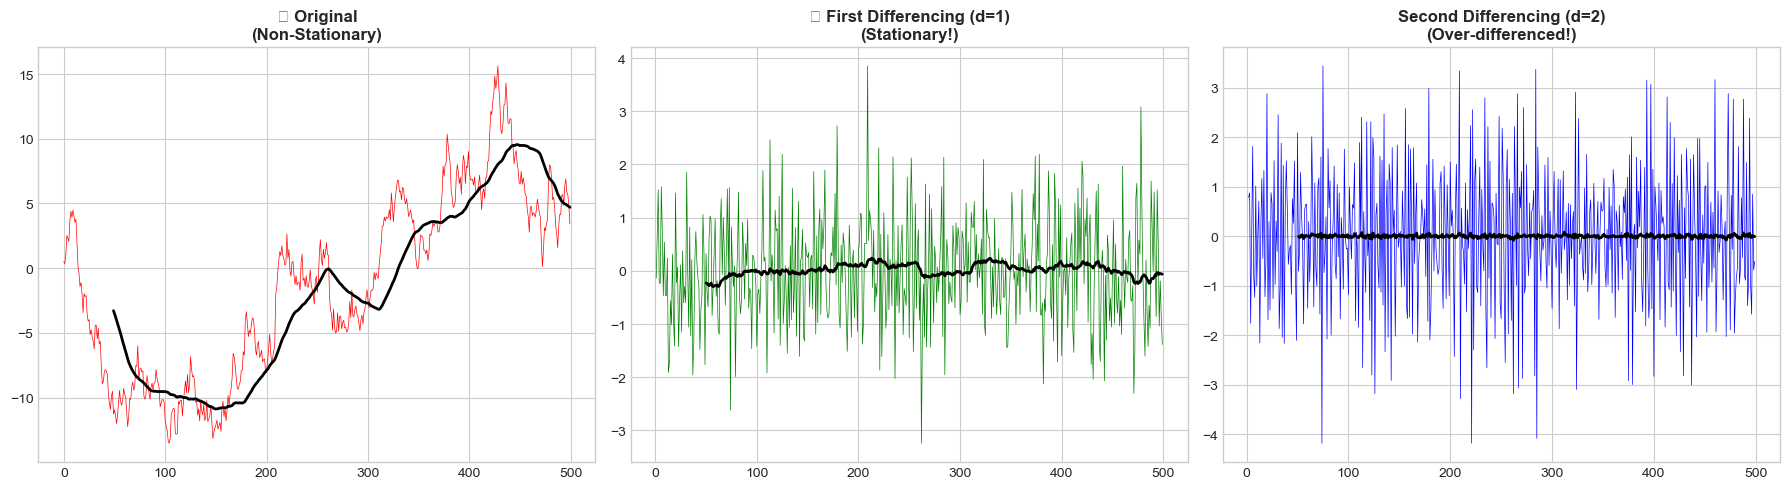

ADF Test Results:
╔══════════════════════════════════════╗
║   ADF Test: Original                 ║
╠══════════════════════════════════════╣
║  ADF Statistic :            -1.4986  ║
║  p-value       :           0.534189  ║
║  # Lags Used   :                  0  ║
║  # Observations:                499  ║
╠══════════════════════════════════════╣
║  Critical Values:                    ║
║    1% :                        -3.4435  ║
║    5% :                        -2.8673  ║
║    10%:                        -2.5699  ║
╠══════════════════════════════════════╣
║  ❌ p=0.5342 ≥ 0.05              ║
║  → Chấp nhận H₀: NON-STATIONARY     ║
╚══════════════════════════════════════╝

╔══════════════════════════════════════╗
║   ADF Test: After d=1                ║
╠══════════════════════════════════════╣
║  ADF Statistic :           -22.3130  ║
║  p-value       :           0.000000  ║
║  # Lags Used   :                  0  ║
║  # Observations:                498  ║
╠══════════════════════════════════

In [5]:
# Differencing trên Random Walk
np.random.seed(42)
random_walk = np.cumsum(np.random.normal(0, 1, 500))
rw_series = pd.Series(random_walk)

# First-order differencing
diff_1 = rw_series.diff().dropna()  # Y(t) - Y(t-1)

# Second-order differencing
diff_2 = rw_series.diff().diff().dropna()  # Diff của diff

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(rw_series, color='red', linewidth=0.5)
axes[0].set_title('❌ Original\n(Non-Stationary)', fontweight='bold')
axes[0].plot(rw_series.rolling(50).mean(), color='black', linewidth=2)

axes[1].plot(diff_1, color='green', linewidth=0.5)
axes[1].set_title('✅ First Differencing (d=1)\n(Stationary!)', fontweight='bold')
axes[1].plot(diff_1.rolling(50).mean(), color='black', linewidth=2)

axes[2].plot(diff_2, color='blue', linewidth=0.5)
axes[2].set_title('Second Differencing (d=2)\n(Over-differenced!)', fontweight='bold')
axes[2].plot(diff_2.rolling(50).mean(), color='black', linewidth=2)

plt.tight_layout()
plt.show()

# ADF Test
print('ADF Test Results:')
adf_test(rw_series, 'Original')
adf_test(diff_1, 'After d=1')

print('\n💡 Thông thường, d=1 là đủ!')
print('💡 Nếu d=1 chưa stationary → Thử d=2')
print('⚠️ KHÔNG nên diff quá 2 lần (over-differencing gây mất thông tin)')

### 📝 Ví dụ 5: Log Transformation

**Khi nào dùng:**
- Variance tăng theo thời gian (dạng hình quạt)
- Dữ liệu có tính multiplicative
- Giá trị dao động theo **tỷ lệ** chứ không theo **giá trị tuyệt đối**

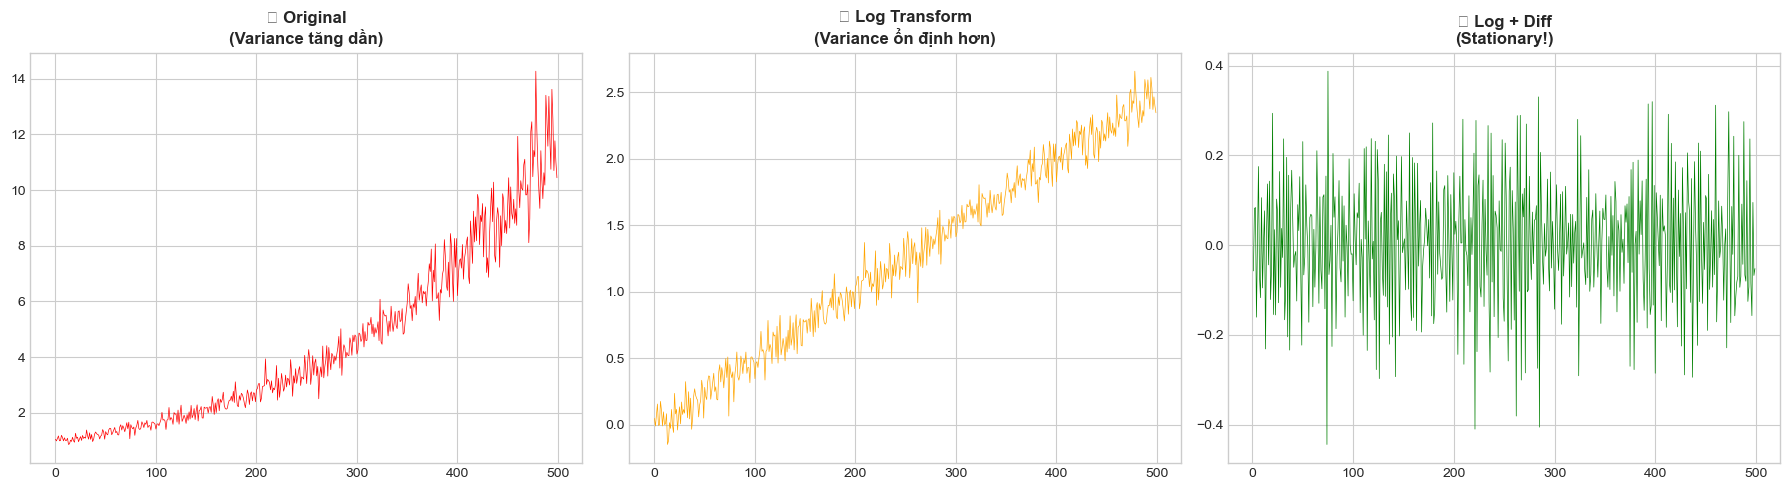

ADF Test:
╔══════════════════════════════════════╗
║   ADF Test: Original                 ║
╠══════════════════════════════════════╣
║  ADF Statistic :             4.9771  ║
║  p-value       :           1.000000  ║
║  # Lags Used   :                 15  ║
║  # Observations:                484  ║
╠══════════════════════════════════════╣
║  Critical Values:                    ║
║    1% :                        -3.4439  ║
║    5% :                        -2.8675  ║
║    10%:                        -2.5700  ║
╠══════════════════════════════════════╣
║  ❌ p=1.0000 ≥ 0.05              ║
║  → Chấp nhận H₀: NON-STATIONARY     ║
╚══════════════════════════════════════╝

╔══════════════════════════════════════╗
║   ADF Test: Log                      ║
╠══════════════════════════════════════╣
║  ADF Statistic :            -0.4476  ║
║  p-value       :           0.901836  ║
║  # Lags Used   :                 15  ║
║  # Observations:                484  ║
╠══════════════════════════════════════╣
║ 

In [6]:
# Tạo dữ liệu có variance tăng dần
np.random.seed(42)
n = 500
t = np.arange(n)

# Exponential growth + increasing variance
y = np.exp(0.005 * t) * (1 + np.random.normal(0, 0.1, n))
series = pd.Series(y)

# Log transformation
log_series = np.log(series)

# Log + Differencing
log_diff = log_series.diff().dropna()

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(series, color='red', linewidth=0.5)
axes[0].set_title('❌ Original\n(Variance tăng dần)', fontweight='bold')

axes[1].plot(log_series, color='orange', linewidth=0.5)
axes[1].set_title('🔸 Log Transform\n(Variance ổn định hơn)', fontweight='bold')

axes[2].plot(log_diff, color='green', linewidth=0.5)
axes[2].set_title('✅ Log + Diff\n(Stationary!)', fontweight='bold')

plt.tight_layout()
plt.show()

# ADF Test
print('ADF Test:')
adf_test(series, 'Original')
adf_test(log_series, 'Log')
adf_test(log_diff, 'Log + Diff')

print('\n💡 Combo LOG + DIFFERENCING là kỹ thuật rất phổ biến!')
print('💡 Log ổn định variance → Diff loại bỏ trend')

### 📝 Ví dụ 6: Seasonal Differencing

**Regular differencing:** Y'(t) = Y(t) - Y(t-1) → Loại trend

**Seasonal differencing:** Y'(t) = Y(t) - Y(t-m) → Loại seasonality
- m = 12 cho monthly data
- m = 7 cho daily data (weekly season)
- m = 4 cho quarterly data

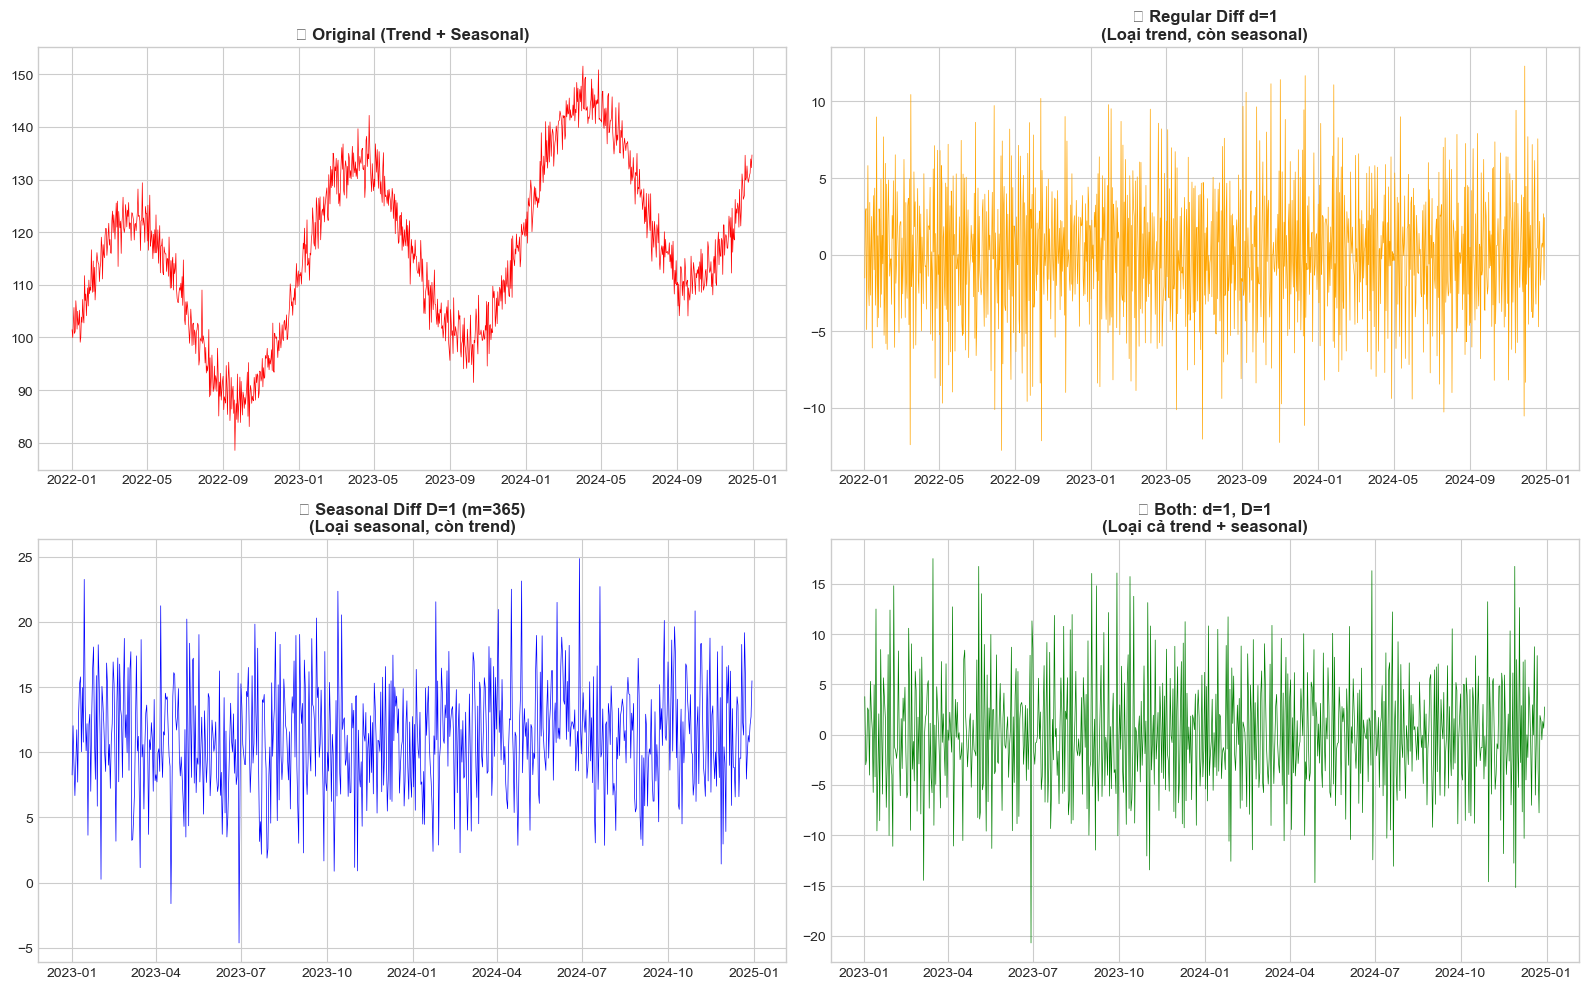

💡 Regular Diff (d=1): Loại trend
💡 Seasonal Diff (D=1): Loại seasonality
💡 Kết hợp cả hai: Loại hết → Stationary!


In [7]:
# Tạo dữ liệu có cả trend + seasonality
np.random.seed(42)
n = 365 * 3
t = np.arange(n)
dates = pd.date_range('2022-01-01', periods=n, freq='D')

trend = 0.03 * t
seasonality = 20 * np.sin(2 * np.pi * t / 365)
noise = np.random.normal(0, 3, n)
y = trend + seasonality + noise + 100

series = pd.Series(y, index=dates)

# Các loại differencing
diff_regular = series.diff(1).dropna()         # d=1: loại trend
diff_seasonal = series.diff(365).dropna()       # D=1 (m=365): loại seasonality
diff_both = series.diff(365).diff(1).dropna()   # Cả hai

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(series, linewidth=0.5, color='red')
axes[0,0].set_title('❌ Original (Trend + Seasonal)', fontweight='bold')

axes[0,1].plot(diff_regular, linewidth=0.5, color='orange')
axes[0,1].set_title('🔸 Regular Diff d=1\n(Loại trend, còn seasonal)', fontweight='bold')

axes[1,0].plot(diff_seasonal, linewidth=0.5, color='blue')
axes[1,0].set_title('🔸 Seasonal Diff D=1 (m=365)\n(Loại seasonal, còn trend)', fontweight='bold')

axes[1,1].plot(diff_both, linewidth=0.5, color='green')
axes[1,1].set_title('✅ Both: d=1, D=1\n(Loại cả trend + seasonal)', fontweight='bold')

plt.tight_layout()
plt.show()

print('💡 Regular Diff (d=1): Loại trend')
print('💡 Seasonal Diff (D=1): Loại seasonality')
print('💡 Kết hợp cả hai: Loại hết → Stationary!')

### 📝 Ví dụ 7: Quy Trình Hoàn Chỉnh Kiểm Tra & Biến Đổi

In [8]:
def make_stationary(series, name='Data'):
    """
    Quy trình tự động biến đổi time series thành stationary
    
    Bước 1: Test ADF gốc
    Bước 2: Nếu non-stationary → Thử differencing d=1
    Bước 3: Nếu vẫn chưa → Thử log + differencing
    Bước 4: Nếu vẫn chưa → Thử d=2
    """
    print(f'\n{"="*60}')
    print(f'  QUY TRÌNH BIẾN ĐỔI: {name}')
    print(f'{"="*60}')
    
    results = []
    
    # Bước 1: Test gốc
    print('\n📌 Bước 1: Test dữ liệu gốc')
    p1 = adfuller(series.dropna())[1]
    print(f'   ADF p-value = {p1:.6f}', '✅' if p1 < 0.05 else '❌')
    results.append(('Original', series, p1))
    
    if p1 < 0.05:
        print('   → Đã stationary! Không cần biến đổi.')
        return series, 0
    
    # Bước 2: Differencing d=1
    print('\n📌 Bước 2: Thử Differencing (d=1)')
    diff1 = series.diff().dropna()
    p2 = adfuller(diff1)[1]
    print(f'   ADF p-value = {p2:.6f}', '✅' if p2 < 0.05 else '❌')
    results.append(('Diff d=1', diff1, p2))
    
    if p2 < 0.05:
        print('   → Stationary sau d=1!')
        return diff1, 1
    
    # Bước 3: Log + Differencing
    print('\n📌 Bước 3: Thử Log + Differencing')
    if (series > 0).all():
        log_diff = np.log(series).diff().dropna()
        p3 = adfuller(log_diff)[1]
        print(f'   ADF p-value = {p3:.6f}', '✅' if p3 < 0.05 else '❌')
        results.append(('Log+Diff', log_diff, p3))
        
        if p3 < 0.05:
            print('   → Stationary sau log + diff!')
            return log_diff, 'log+1'
    
    # Bước 4: d=2
    print('\n📌 Bước 4: Thử Differencing (d=2)')
    diff2 = series.diff().diff().dropna()
    p4 = adfuller(diff2)[1]
    print(f'   ADF p-value = {p4:.6f}', '✅' if p4 < 0.05 else '❌')
    results.append(('Diff d=2', diff2, p4))
    
    return diff2, 2

# Test trên dữ liệu thực
np.random.seed(42)
test_data = pd.Series(np.cumsum(np.random.normal(0.1, 1, 300)))  # Random walk with drift
stationary_data, d = make_stationary(test_data, 'Random Walk with Drift')


  QUY TRÌNH BIẾN ĐỔI: Random Walk with Drift

📌 Bước 1: Test dữ liệu gốc
   ADF p-value = 0.968797 ❌

📌 Bước 2: Thử Differencing (d=1)
   ADF p-value = 0.000000 ✅
   → Stationary sau d=1!


---
## 🏋️ BÀI TẬP THỰC HÀNH
---

### Bài 1: ADF Test Cơ Bản (⭐ Dễ)

Tạo 3 loại time series:
1. White noise (stationary)
2. Random walk (non-stationary)
3. Sine wave thuần (stationary)

Chạy ADF test cho từng loại và giải thích kết quả.

In [11]:
# TODO: Viết code ở đây
white_nose = np.random.normal(0,1,500)#white noise variance ổn định
random_walk = np.cumsum(np.random.normal(0,1,500))#random walk có unit root
sine_wave_trend = 0.05 * np.arange(500) + 10 * np.sin(2 * np.pi * np.arange(500)/ 50) + np.random.normal(0,1,500)

def ADF_test(series , name = ''):
    result = adfuller(series.dropna())
    print(f"ADF statistic : {result[0]:.4f}")
    print(f"p-value: {result[1]:.6f}")
    for key , value in result[4].items():
        print(f"Critical value {key}: {value:.4f}")
    if result[1]< 0.05: 
        print(f"{name} is stationary (reject H0)")
    else:
        print(f"{name} is non-stationary (fail to reject H0)")
    return result[1]


print("ADF test for white noise:")
ADF_test(pd.Series(white_nose), 'white noise')
print("\nADF test for random walk:")
ADF_test(pd.Series(random_walk), 'random walk')
print("\nADF test for sine wave with trend:")
ADF_test(pd.Series(sine_wave_trend), 'sine wave with trend')

ADF test for white noise:
ADF statistic : -17.2491
p-value: 0.000000
Critical value 1%: -3.4435
Critical value 5%: -2.8674
Critical value 10%: -2.5699
white noise is stationary (reject H0)

ADF test for random walk:
ADF statistic : -1.1361
p-value: 0.700464
Critical value 1%: -3.4435
Critical value 5%: -2.8673
Critical value 10%: -2.5699
random walk is non-stationary (fail to reject H0)

ADF test for sine wave with trend:
ADF statistic : -1.4930
p-value: 0.536952
Critical value 1%: -3.4440
Critical value 5%: -2.8676
Critical value 10%: -2.5700
sine wave with trend is non-stationary (fail to reject H0)


np.float64(0.5369516887430332)

### Bài 2: Differencing Thực Tế (⭐⭐ Trung bình)

Sử dụng `retail_sales_dataset.csv`:
1. Chọn cột doanh số, set date index
2. Kiểm tra stationarity bằng ADF test
3. Nếu non-stationary: áp dụng differencing (d=1)
4. Kiểm tra lại ADF test
5. Vẽ biểu đồ before/after

In [ ]:
# TODO: Viết code ở đây

### Bài 3: So Sánh Các Phương Pháp (⭐⭐⭐ Nâng cao)

Tạo dữ liệu non-stationary có:
- Exponential trend
- Increasing variance
- Seasonality

Áp dụng tuần tự các phương pháp sau và so sánh:
1. Differencing (d=1)
2. Log transformation
3. Log + Differencing
4. Seasonal decomposition (lấy residual)

Chạy ADF + KPSS test cho mỗi phương pháp. Phương pháp nào tốt nhất?

In [ ]:
# TODO: Viết code ở đây

---
# 🧠 PHẦN ÔN TẬP & CỦNG CỐ KIẾN THỨC - CHƯƠNG 3

---

## 1️⃣ Nguyên Lí 80/20: 20% Kiến Thức Cốt Lõi Mang Lại 80% Giá Trị

> **Nếu bạn chỉ nhớ được 3 điều từ chương này, hãy nhớ:**

### 🔑 Kiến thức #1: Stationary = Mean + Variance KHÔNG ĐỔI theo thời gian
- **Stationary:** Dữ liệu dao động quanh một mức trung bình cố định, biên độ ổn định
- **Non-Stationary:** Mean thay đổi (trend) HOẶC Variance thay đổi → Model sai!
- **Tại sao quan trọng?** Hầu hết model cổ điển (ARIMA, SARIMA) **BẮT BUỘC** data phải stationary

### 🔑 Kiến thức #2: ADF Test — Kiểm tra 1 dòng code
```python
from statsmodels.tsa.stattools import adfuller

result = adfuller(data)
p_value = result[1]

if p_value < 0.05:
    print("✅ STATIONARY — Dùng model được!")
else:
    print("❌ NON-STATIONARY — Cần xử lý trước!")
```
- **p < 0.05 → Stationary** (bác bỏ H0: non-stationary)
- **p ≥ 0.05 → Non-Stationary** (chưa đủ bằng chứng)

### 🔑 Kiến thức #3: Differencing — Thuốc chữa bách bệnh cho Non-Stationary
```python
# Differencing bậc 1: Y'(t) = Y(t) - Y(t-1)
data_diff = data.diff().dropna()

# Nếu vẫn non-stationary → Differencing bậc 2:
data_diff2 = data.diff().diff().dropna()
```
- **d=1:** Giải quyết ~90% trường hợp non-stationary
- **d=2:** Giải quyết hầu hết phần còn lại
- **d≥3:** Rất hiếm cần, nếu cần → xem lại data

> **Một câu tóm tắt:** *"Kiểm tra stationarity bằng ADF test (p<0.05 = OK), nếu không OK thì differencing cho đến khi OK."*

---

## 2️⃣ Mô Hình Hóa Kiến Thức: Phép Ẩn Dụ "Đi Bộ Trên Đường"

### 🚶 Câu chuyện: Stationarity giống như CÁCH BẠN ĐI BỘ

**Người đi bộ Stationary: Đi bộ quanh sân nhà** 🏠
```
     ╱╲   ╱╲   ╱╲   ╱╲
────╱──╲─╱──╲─╱──╲─╱──╲────  ← Mean cố định
        ╲╱   ╲╱   ╲╱
```
- Luôn quay về gần nhà (mean cố định)
- Bước chân đều đặn (variance cố định)
- Dự đoán được: "5 phút nữa vẫn ở gần nhà"

**Người đi bộ Non-Stationary: Leo núi** ⛰️
```
                              ╱╲
                         ╱╲ ╱  ╲
                    ╱╲ ╱  ╲╱
               ╱╲ ╱  ╲╱
          ╱╲ ╱  ╲╱
     ╱╲ ╱  ╲╱
────╱  ╲╱                    ← Mean TĂNG DẦN!
```
- Càng lúc càng xa nhà (mean thay đổi)
- Bước leo ngày càng vất vả (variance có thể tăng)
- Khó dự đoán: "5 phút nữa ở đâu?"

**Differencing = Đo BƯỚC CHÂN thay vì VỊ TRÍ:**
- Thay vì hỏi "Bạn đang ở đâu?" (non-stationary vì đang leo)
- Hỏi "Mỗi bước bạn đi bao xa?" (stationary! vì mỗi bước ~0.5m)
- **Differencing biến vị trí (non-stationary) → bước chân (stationary)**

### 🎨 Sơ đồ quy trình:
```
  Data thô
     │
     ▼
  ┌────────────────┐
  │  ADF Test      │
  │  p-value < 0.05│──── YES ──→ ✅ STATIONARY
  └────────┬───────┘            → Dùng ARIMA được!
           │ NO
           ▼
  ┌────────────────┐
  │ Nhìn đồ thị   │
  │ Variance tăng? │──── YES ──→ Log Transform trước
  └────────┬───────┘            → rồi quay lại ADF
           │ NO
           ▼
  ┌────────────────┐
  │ Differencing   │
  │ d = 1          │──── ADF lại ──→ p < 0.05? ✅
  └────────┬───────┘
           │ Vẫn NO
           ▼
  ┌────────────────┐
  │ Differencing   │
  │ d = 2          │──── Thường là đủ ✅
  └────────────────┘
```

---

## 3️⃣ Liên Tưởng Với Cuộc Sống

### 🏋️ Cân nặng hàng ngày
- **Non-Stationary:** Bạn đang giảm cân → Cân nặng giảm dần qua các tuần (trend giảm)
- **Differencing:** Thay vì nhìn cân nặng tuyệt đối, nhìn "hôm nay giảm/tăng bao nhiêu so với hôm qua" → Dao động quanh -0.1kg/ngày (stationary!)
- **ADF test:** Giống như hỏi "Bạn có đang ở một mức cân ổn định không?"

### 🌊 Mực nước sông
- **Stationary:** Hồ nước trong công viên — mực nước dao động quanh mức cố định
- **Non-Stationary:** Sông Mekong mùa lũ — mực nước tăng dần rồi giảm (trend)
- **Differencing:** Đo "mỗi ngày nước dâng/rút bao nhiêu cm" thay vì mực nước tuyệt đối

### 💰 Giá Bitcoin
- **Rõ ràng Non-Stationary:** Từ $1,000 (2017) → $60,000 (2021) → Mean thay đổi chóng mặt
- **Log Transform:** Biến giá trị tuyệt đối → tỷ lệ phần trăm thay đổi
- **Differencing:** Đo "hôm nay tăng/giảm bao nhiêu %" → Gần stationary hơn

### 📱 Số tin nhắn bạn gửi mỗi ngày
- Nếu bạn gửi ~50 tin/ngày, dao động 40-60 → **Stationary** ✅
- Nếu bạn vừa yêu, tin nhắn tăng từ 50 → 200/ngày → **Non-Stationary** ❌ (trend tăng)
- Sau khi quen rồi, tin nhắn ổn định ~100/ngày → **Stationary lại** ✅

---

## 4️⃣ Teach to Learn — Giảng Lại Để Hiểu Sâu

### 📝 Bài tập 1: Giải thích Stationarity cho "người không biết gì"
> Dùng ví dụ **nhiệt độ phòng máy lạnh** (stationary) vs **giá xăng qua các năm** (non-stationary).
> Viết 5 câu giải thích tại sao ARIMA cần stationarity.

In [ ]:
# ✍️ BÀI TẬP 1: Giải thích Stationarity cho "người không biết gì"
# Dùng ví dụ nhiệt độ phòng máy lạnh (stationary) vs giá xăng (non-stationary)

"""
Viết câu trả lời ở đây (5 câu, không dùng công thức toán):

1. Stationary là khi: _______________
2. Ví dụ stationary (phòng máy lạnh): _______________
3. Non-stationary là khi: _______________
4. Ví dụ non-stationary (giá xăng): _______________
5. Tại sao ARIMA cần stationarity: _______________
"""

In [ ]:
# ✍️ BÀI TẬP 2: Viết quy trình kiểm tra stationarity từng bước
# Bạn nhận data doanh số 3 năm → viết quy trình xử lý

"""
QUY TRÌNH CỦA TÔI:

Bước 1: _______________
Bước 2: Nếu p > 0.05 (non-stationary), tôi sẽ: _______________
Bước 3: Khi nào dùng Log Transform? _______________
Bước 4: Khi nào dùng Differencing? _______________
Bước 5: Khi nào dùng cả Log + Differencing? _______________
"""

# Viết code minh họa quy trình:
# import pandas as pd
# import numpy as np
# from statsmodels.tsa.stattools import adfuller
# 
# # Bước 1: Load data và kiểm tra ADF
# # result = adfuller(data)
# # print(f"p-value: {result[1]}")
# 
# # Bước 2: Nếu non-stationary...
# # data_diff = data.diff().dropna()
# # result2 = adfuller(data_diff)
# # print(f"After diff - p-value: {result2[1]}")

In [ ]:
# ✍️ BÀI TẬP 3: Đọc kết quả ADF Test và phân tích
# Cho kết quả ADF test, hãy diễn giải

"""
KẾT QUẢ ADF TEST:
  ADF Statistic: -1.23
  p-value: 0.6612
  Critical Values: 1%: -3.44, 5%: -2.87, 10%: -2.57

CÂU HỎI:
1. Data này stationary hay non-stationary? _______________
   Tại sao? _______________

2. ADF Statistic (-1.23) so với critical value 5% (-2.87):
   -1.23 có "âm hơn" (nhỏ hơn) -2.87 không? _______________
   Kết luận: _______________

3. Bước tiếp theo bạn sẽ làm gì? _______________
   Code: _______________
"""